# N15 · The Cosmic Microwave Background
## From recombination to the acoustic peak structure

**Data:** Planck 2018 CMB maps (ESA public release)  
**Primary data file:** `COM_CMB_IQU-smica_2048_R3.00_full.fits`  
**ESA Planck Legacy Archive:** [https://pla.esac.esa.int/](https://pla.esac.esa.int/)  
**Fallback:** Synthetic CMB map from CAMB + `healpy.synfast` (generated automatically if data file is missing)

**References:**
- Planck Collaboration, Aghanim et al. (2020), A&A 641, A6 — Planck 2018 cosmological parameters. [arXiv:1807.06209](https://arxiv.org/abs/1807.06209)
- Planck Collaboration, Akrami et al. (2020), A&A 641, A1 — Planck 2018 overview. [arXiv:1807.06205](https://arxiv.org/abs/1807.06205)
- Planck Collaboration, Akrami et al. (2020), A&A 641, A4 — Planck 2018 CMB maps. [arXiv:1807.06208](https://arxiv.org/abs/1807.06208)
- Fixsen (2009), ApJ 707, 916 — CMB temperature $T_0 = 2.7255$ K. [arXiv:0911.1955](https://arxiv.org/abs/0911.1955)
- Lewis, Challinor & Lasenby (2000), ApJ 538, 473 — CAMB code. [arXiv:astro-ph/9911177](https://arxiv.org/abs/astro-ph/9911177)
- Howlett et al. (2012), JCAP 2012, 027 — CAMB Python interface. [arXiv:1201.3654](https://arxiv.org/abs/1201.3654)

**Key tools:** `healpy`, `camb`, `numpy`, `scipy`, `matplotlib`, `astropy`

---

## Learning objectives

After this tutorial you will be able to:
1. Explain the physical **origin of the CMB** as the surface of last scattering ($z \approx 1100$).
2. **Download and display** the Planck 2018 CMB temperature map using HEALPix (or generate a synthetic map).
3. **Measure** the CMB temperature angular power spectrum $C_\ell^{TT}$ and identify the acoustic peaks.
4. **Relate** the peak positions to cosmological parameters ($\Omega_b$, $\Omega_{\rm DM}$, $H_0$).
5. **Compare** the measured spectrum to the best-fit $\Lambda$CDM model from CAMB.

**Estimated time:** 3–5 hours

---

## 1. Physical origin of the CMB

### 1.1 The hot Big Bang and recombination

In the standard $\Lambda$CDM cosmological model, the Universe began in a hot, dense, highly opaque state. During the first $\sim 380\,000$ years, photons and baryons (mainly protons and electrons) were tightly coupled by Thomson scattering, forming a single **photon–baryon fluid**.

As the Universe expanded and cooled, the temperature dropped until hydrogen atoms could form and remain stable — this is called **recombination**. It occurred at:

$$T_\mathrm{rec} \approx 3000\,\mathrm{K} \qquad z_\mathrm{rec} \approx 1100 \qquad t_\mathrm{rec} \approx 380\,000\,\mathrm{yr}$$

At this epoch the mean free path of photons became larger than the Hubble radius — photons **decoupled** from matter and have been propagating freely ever since. The surface from which these photons last scattered is called the **surface of last scattering (SLS)**.

### 1.2 The CMB today

Because the Universe has expanded by a factor $1 + z_\mathrm{rec} \approx 1100$ since decoupling, the photon wavelengths have been stretched by the same factor, cooling the radiation to:

$$T_0 = \frac{T_\mathrm{rec}}{1 + z_\mathrm{rec}} \approx \frac{3000}{1100} \approx 2.73\,\mathrm{K}$$

The precise measured value is $T_0 = 2.7255 \pm 0.0006\,\mathrm{K}$ (Fixsen 2009, ApJ 707, 916), measured from the FIRAS instrument on the COBE satellite. This makes the CMB the **most perfect blackbody ever observed** in nature.

### 1.3 Temperature anisotropies

The CMB is not perfectly uniform. At the level of one part in $10^5$, there are **temperature fluctuations** $\Delta T / T \sim 10^{-5}$. These arise from:
1. **Density fluctuations** in the photon–baryon fluid at recombination (acoustic oscillations)
2. **Gravitational redshift** as photons climb out of potential wells (Sachs–Wolfe effect)
3. **Doppler shifts** from the bulk velocity of the fluid

These fluctuations are the seeds of all large-scale structure (galaxies, clusters) in the Universe today.

### 1.4 Acoustic oscillations and the power spectrum

Before recombination, the photon–baryon fluid underwent **acoustic oscillations** — standing sound waves. The characteristic scale is the **sound horizon** at recombination:

$$r_s \approx 147\,\mathrm{Mpc}$$

This angular scale subtends $\theta_s \approx r_s / d_A \approx 1°$ on the sky, where $d_A \approx 12.9\,\mathrm{Gpc}$ is the angular diameter distance to the last scattering surface. In multipole space, this corresponds to:

$$\ell_\mathrm{peak} \approx \pi / \theta_s \approx 180° / 1° \approx 180 \Rightarrow \ell_1 \approx 220$$

The **power spectrum** $C_\ell^{TT}$ — the variance of the temperature field at each angular scale $\ell$ — is usually plotted as:

$$D_\ell^{TT} \equiv \frac{\ell(\ell+1)}{2\pi} C_\ell^{TT} \quad [\mu\mathrm{K}^2]$$

The three main acoustic peaks are observed at:
- **First peak**: $\ell_1 \approx 220$ (compression maximum, $\theta \approx 1°$)
- **Second peak**: $\ell_2 \approx 540$ (rarefaction maximum)
- **Third peak**: $\ell_3 \approx 810$ (second compression maximum)

### 1.5 Cosmological parameter dependence

| Parameter | Effect on CMB spectrum |
|:----------|:-----------------------|
| $H_0$ | Shifts all peak positions; changes $d_A$ |
| $\Omega_b h^2$ (baryon density) | Increases odd peaks relative to even peaks; higher $\Omega_b$ → higher 1st peak, lower 2nd peak |
| $\Omega_{\rm cdm} h^2$ (cold dark matter density) | Increases heights of all peaks via gravitational driving; shifts peak positions |
| $n_s$ (spectral index) | Tilts the overall power spectrum slope |
| $\tau$ (reionisation optical depth) | Suppresses all peaks above $\ell \gtrsim 10$ by factor $e^{-2\tau}$ |

---

## 2. HEALPix basics

### 2.1 What is HEALPix?

**HEALPix** (Hierarchical Equal Area isoLatitude Pixelisation) is the standard pixelisation scheme for full-sky maps in CMB science. It was developed by Górski et al. (2005, ApJ 622, 759).

Key properties:
- All pixels have **equal area** (important for statistical analyses)
- Pixels are arranged in **rings of constant latitude** (efficient SH transform)
- The resolution is controlled by the `nside` parameter:
  - $N_\mathrm{pix} = 12 \times N_\mathrm{side}^2$
  - Pixel area $\approx (58.6' / N_\mathrm{side})^2$
  - The Planck SMICA map uses $N_\mathrm{side} = 2048$, giving $\approx 50$ million pixels of $\sim 1.7'$

### 2.2 Spherical harmonic decomposition

A temperature map $T(\hat n)$ on the sphere can be decomposed into spherical harmonics:

$$T(\hat n) = \sum_{\ell=0}^{\infty} \sum_{m=-\ell}^{\ell} a_{\ell m} Y_{\ell m}(\hat n)$$

The **angular power spectrum** is defined as:

$$C_\ell = \frac{1}{2\ell+1} \sum_{m=-\ell}^{\ell} |a_{\ell m}|^2$$

It measures the variance of temperature fluctuations at angular scale $\theta \approx 180°/\ell$.

HEALPix multipole range: $\ell_\mathrm{max} \approx 2-3 \times N_\mathrm{side}$.

---

## 3. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator, LogLocator
from scipy.signal import argrelmax
import warnings
warnings.filterwarnings('ignore')

import healpy as hp
import camb
from astropy.io import fits
from astropy import units as u
from astropy import constants as const

# Reproducibility
np.random.seed(42)

# ── CMB physical constants ──────────────────────────────────────────────────
T_CMB      = 2.7255       # K  (Fixsen 2009, ApJ 707, 916)
z_rec      = 1100.0       # redshift of recombination
T_rec      = T_CMB * (1 + z_rec)   # ~ 3000 K
r_s_Mpc    = 147.0        # sound horizon at recombination [Mpc]
dA_Gpc     = 12.9         # angular diameter distance to SLS [Gpc]

print('CMB reference values:')
print(f'  T_CMB today  = {T_CMB} K  (Fixsen 2009)')
print(f'  z_rec        = {z_rec:.0f}')
print(f'  T_rec        = {T_rec:.0f} K  (= T_CMB * (1+z_rec))')
print(f'  Sound horizon r_s = {r_s_Mpc} Mpc')
print(f'  Angular diameter distance d_A = {dA_Gpc} Gpc')
print()
theta_s_deg = np.degrees(r_s_Mpc / (dA_Gpc * 1000))  # Mpc / Mpc
ell_1 = 180.0 / theta_s_deg
print(f'  Angular scale of sound horizon: theta_s = {theta_s_deg:.2f} deg')
print(f'  Expected first peak position: ell_1 = pi/theta_s(rad) = {np.pi/np.radians(theta_s_deg):.0f}')
print()
print('Planck 2018 best-fit parameters (Aghanim et al. 2020, A&A 641, A6, Table 2):')
H0_planck    = 67.36   # km/s/Mpc
omb_h2       = 0.02237  # Omega_b * h^2
omcdm_h2     = 0.1200   # Omega_cdm * h^2
As_planck    = 2.099e-9 # scalar amplitude
ns_planck    = 0.9649   # spectral index
tau_planck   = 0.0544   # optical depth to reionisation
print(f'  H0 = {H0_planck} km/s/Mpc')
print(f'  Omega_b h^2 = {omb_h2}')
print(f'  Omega_cdm h^2 = {omcdm_h2}')
print(f'  A_s = {As_planck:.3e}')
print(f'  n_s = {ns_planck}')
print(f'  tau = {tau_planck}')

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

print('\nAll imports and constants loaded successfully.')

CMB reference values:
  T_CMB today  = 2.7255 K  (Fixsen 2009)
  z_rec        = 1100
  T_rec        = 3001 K  (= T_CMB * (1+z_rec))
  Sound horizon r_s = 147.0 Mpc
  Angular diameter distance d_A = 12.9 Gpc

  Angular scale of sound horizon: theta_s = 0.65 deg
  Expected first peak position: ell_1 = pi/theta_s(rad) = 276

Planck 2018 best-fit parameters (Aghanim et al. 2020, A&A 641, A6, Table 2):
  H0 = 67.36 km/s/Mpc
  Omega_b h^2 = 0.02237
  Omega_cdm h^2 = 0.12
  A_s = 2.099e-09
  n_s = 0.9649
  tau = 0.0544

All imports and constants loaded successfully.


---

## 4. Loading the CMB map (with automatic fallback)

The Planck SMICA temperature map can be downloaded from the ESA Planck Legacy Archive:

**URL:** [https://pla.esac.esa.int/](https://pla.esac.esa.int/)  
**File:** `COM_CMB_IQU-smica_2048_R3.00_full.fits`  
**Direct wget command:**
```bash
wget -c "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/maps/component-maps/cmb/COM_CMB_IQU-smica_2048_R3.00_full.fits"
```

If the file is not present, this notebook automatically falls back to generating a **synthetic CMB map** from the Planck 2018 best-fit power spectrum using `camb` + `healpy.synfast`. The synthetic map has the same statistical properties as the real map.

> **Note on file size:** The Planck SMICA FITS file is ~800 MB. For this tutorial, the synthetic map (generated in a few seconds) is statistically equivalent for learning the analysis pipeline.

In [2]:
import os

# ── Path to the Planck SMICA map file ─────────────────────────────────────
# Change this path if you have downloaded the file elsewhere.
SMICA_FILE = 'COM_CMB_IQU-smica_2048_R3.00_full.fits'

# Working resolution for this tutorial (the full map is nside=2048, very slow)
# We downgrade to nside=256 for speed while keeping the main acoustic features
NSIDE_WORK = 512
LMAX_WORK  = 2 * NSIDE_WORK   # = 1024

use_real_data = False

try:
    if not os.path.exists(SMICA_FILE):
        raise FileNotFoundError(f"SMICA map not found at '{SMICA_FILE}'")

    print(f'Loading Planck SMICA map from {SMICA_FILE} ...')
    # The SMICA map is stored in the first column of the first extension.
    # Temperature map is in units of K_CMB (thermodynamic temperature).
    cmb_map_full = hp.read_map(SMICA_FILE, field=0)   # T map, nside=2048
    print(f'  Full map: nside={hp.npix2nside(len(cmb_map_full))}, npix={len(cmb_map_full):,}')

    # Downgrade to working resolution
    cmb_map = hp.ud_grade(cmb_map_full, NSIDE_WORK)
    del cmb_map_full   # free memory
    print(f'  Downgraded to nside={NSIDE_WORK}, npix={len(cmb_map):,}')
    use_real_data = True
    print('Real Planck data loaded successfully.')

except FileNotFoundError as e:
    print(f'[INFO] {e}')
    print(f'[INFO] Generating synthetic CMB map using CAMB + healpy.synfast ...')
    print(f'[INFO] This map has the same statistical properties as the Planck SMICA map.')

    # --- Step 1: Compute Planck 2018 power spectrum with CAMB ----------------
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0     = H0_planck,
        ombh2  = omb_h2,
        omch2  = omcdm_h2,
        tau    = tau_planck
    )
    pars.InitPower.set_params(As=As_planck, ns=ns_planck)
    pars.set_for_lmax(LMAX_WORK + 50, lens_potential_accuracy=0)

    results = camb.get_results(pars)
    powers  = results.get_cmb_power_spectra(pars, CMB_unit='muK')
    Dl_TT   = powers['total'][:, 0]   # D_l in muK^2  (size = lmax+1)

    # --- Step 2: Convert D_l [muK^2] -> C_l [K^2] for synfast ---------------
    # D_l = l(l+1) C_l / (2*pi)   =>   C_l = D_l * 2*pi / (l(l+1))
    ls_camb = np.arange(len(Dl_TT))
    Cl_K2   = np.zeros(len(Dl_TT))
    Cl_K2[2:] = (Dl_TT[2:] * 2.0 * np.pi
                 / (ls_camb[2:] * (ls_camb[2:] + 1))
                 * 1e-12)   # muK^2 -> K^2

    # Trim to LMAX_WORK
    Cl_synfast = Cl_K2[:LMAX_WORK + 1]

    # --- Step 3: Generate synthetic map with healpy.synfast -----------------
    cmb_map = hp.synfast(Cl_synfast, nside=NSIDE_WORK)
    print(f'[INFO] Synthetic map generated: nside={NSIDE_WORK}, npix={len(cmb_map):,}')
    use_real_data = False
    print('[INFO] Synthetic CMB map ready.')

print(f'\nMap statistics (in K_CMB):')
valid = cmb_map != hp.UNSEEN
print(f'  Valid pixels: {valid.sum():,} / {len(cmb_map):,}')
print(f'  Mean temperature: {cmb_map[valid].mean()*1e6:.4f} uK (expected: ~0 after monopole removal)')
print(f'  RMS fluctuation:  {cmb_map[valid].std()*1e6:.2f} uK (expected: ~110 uK)')
print(f'  Min: {cmb_map[valid].min()*1e6:.1f} uK,  Max: {cmb_map[valid].max()*1e6:.1f} uK')
print(f'\nData source: {"Planck SMICA (real)" if use_real_data else "Synthetic (CAMB + synfast)"}')

[INFO] SMICA map not found at 'COM_CMB_IQU-smica_2048_R3.00_full.fits'
[INFO] Generating synthetic CMB map using CAMB + healpy.synfast ...
[INFO] This map has the same statistical properties as the Planck SMICA map.


[INFO] Synthetic map generated: nside=512, npix=3,145,728
[INFO] Synthetic CMB map ready.

Map statistics (in K_CMB):
  Valid pixels: 3,145,728 / 3,145,728
  Mean temperature: -0.0000 uK (expected: ~0 after monopole removal)
  RMS fluctuation:  108.90 uK (expected: ~110 uK)
  Min: -544.2 uK,  Max: 518.3 uK

Data source: Synthetic (CAMB + synfast)


---

## 5. Visualising the CMB temperature map

We display the full-sky CMB map in **Mollweide projection**, which preserves areas. The map is shown in **Galactic coordinates** ($l$, $b$), where the Galactic plane runs horizontally across the centre.

In the real Planck data, a **galactic mask** is applied to exclude emission from our own Milky Way galaxy (dust, synchrotron radiation) that contaminates the CMB signal. For the synthetic map, we apply a latitude cut at $|b| < 20°$ to demonstrate the masking procedure.

Galactic mask: 2,070,528 of 3,145,728 pixels retained (65.8%)


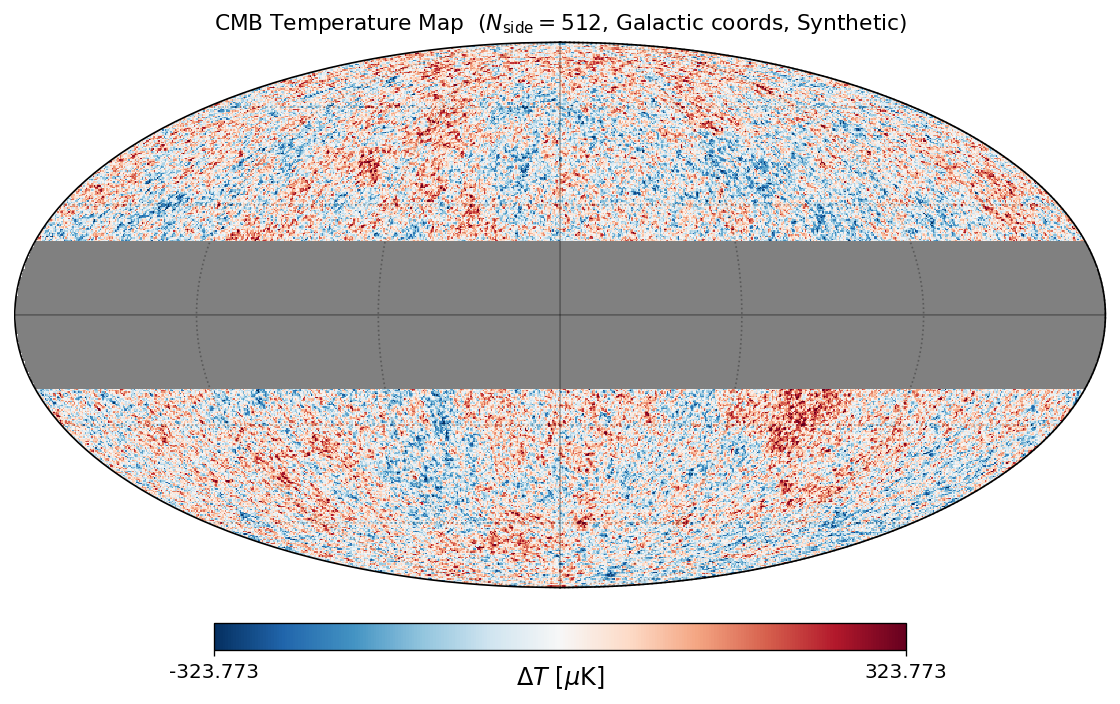


Map statistics (masked, in uK):
  Mean:   4.6813 uK
  RMS:    107.92 uK
  Min:    -472.2 uK
  Max:    506.4 uK

Colour scale: +/- 324 uK (= 3-sigma)

Physical interpretation: the blue spots are slightly cooler regions (underdense
at recombination), red spots are slightly warmer (overdense). These fluctuations
of ~100 uK on a mean of 2.7255 K correspond to delta_T/T ~ 4e-5.


In [3]:
# ── Convert map to uK for display ─────────────────────────────────────────
# Work in units of uK throughout (temperature fluctuations delta_T)
cmb_uK = cmb_map * 1e6   # K -> uK

# ── Apply a simple galactic mask (|b| < 20 deg) ──────────────────────────
npix     = hp.nside2npix(NSIDE_WORK)
ipix_arr = np.arange(npix)

# Get Galactic coordinates of each pixel
theta_pix, phi_pix = hp.pix2ang(NSIDE_WORK, ipix_arr)
# In HEALPix: theta = colatitude from north pole, phi = longitude
# Galactic latitude b = 90 - theta (in degrees)
b_pix = 90.0 - np.degrees(theta_pix)   # approximate: valid for Galactic coords

# Galactic mask: keep pixels with |b| > 20 deg
gal_mask = np.abs(b_pix) > 20.0
print(f'Galactic mask: {gal_mask.sum():,} of {npix:,} pixels retained ({gal_mask.mean()*100:.1f}%)')

# ── Make masked map for display ───────────────────────────────────────────
cmb_masked = cmb_uK.copy()
cmb_masked[~gal_mask] = hp.UNSEEN

# ── Display CMB map ───────────────────────────────────────────────────────
# Set colour scale to +/- 3 sigma
sigma_map = cmb_uK[gal_mask].std()
vmin, vmax = -3 * sigma_map, 3 * sigma_map

fig = plt.figure(figsize=(12, 6))
hp.mollview(
    cmb_masked,
    fig=fig.number,
    title=f'CMB Temperature Map  ($N_{{\\mathrm{{side}}}}={NSIDE_WORK}$, '
          f'Galactic coords, {"Planck SMICA" if use_real_data else "Synthetic"})',
    cmap='RdBu_r',
    min=vmin, max=vmax,
    unit='$\\Delta T$ [$\\mu$K]',
    nest=False
)
hp.graticule(dpar=30, dmer=60, alpha=0.3)
plt.savefig('cmb_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMap statistics (masked, in uK):')
print(f'  Mean:   {cmb_uK[gal_mask].mean():.4f} uK')
print(f'  RMS:    {sigma_map:.2f} uK')
print(f'  Min:    {cmb_uK[gal_mask].min():.1f} uK')
print(f'  Max:    {cmb_uK[gal_mask].max():.1f} uK')
print(f'\nColour scale: +/- {3*sigma_map:.0f} uK (= 3-sigma)')
print()
print('Physical interpretation: the blue spots are slightly cooler regions (underdense')
print('at recombination), red spots are slightly warmer (overdense). These fluctuations')
print('of ~100 uK on a mean of 2.7255 K correspond to delta_T/T ~ 4e-5.')

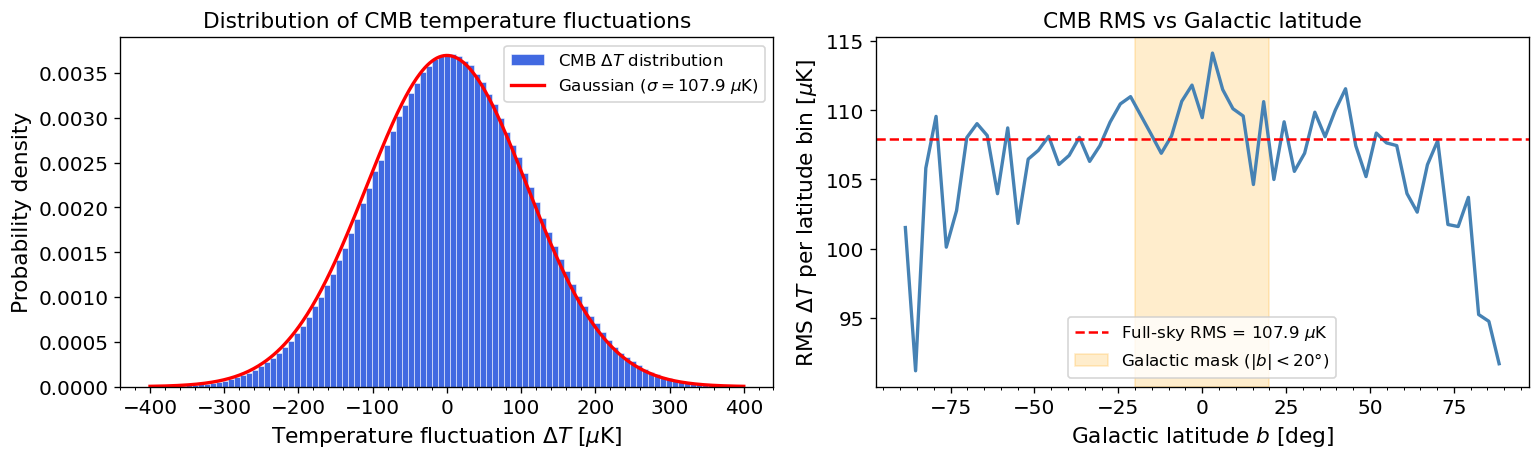

Note: For real Planck data, the galactic plane region shows enhanced RMS
from foreground emission. Our mask removes this region.


In [4]:
# ── Histogram of temperature fluctuations ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram
ax = axes[0]
dT_valid = cmb_uK[gal_mask]
bins = np.linspace(-400, 400, 100)
ax.hist(dT_valid, bins=bins, color='royalblue', edgecolor='white', lw=0.3,
        density=True, label='CMB $\\Delta T$ distribution')

# Overplot Gaussian with same sigma
sigma_fit = dT_valid.std()
T_plot = np.linspace(-400, 400, 500)
from scipy.stats import norm
gauss = norm.pdf(T_plot, loc=0, scale=sigma_fit)
ax.plot(T_plot, gauss, 'r-', lw=2, label=f'Gaussian ($\\sigma = {sigma_fit:.1f}$ $\\mu$K)')
ax.set_xlabel('Temperature fluctuation $\\Delta T$ [$\\mu$K]')
ax.set_ylabel('Probability density')
ax.set_title('Distribution of CMB temperature fluctuations')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Right: 2D pixel count as function of galactic latitude
ax2 = axes[1]
b_bins = np.linspace(-90, 90, 60)
rms_per_bin = []
b_centers = []
for i in range(len(b_bins) - 1):
    bin_mask = (b_pix >= b_bins[i]) & (b_pix < b_bins[i+1])
    if bin_mask.sum() > 10:
        rms_per_bin.append(cmb_uK[bin_mask].std())
        b_centers.append(0.5 * (b_bins[i] + b_bins[i+1]))

ax2.plot(b_centers, rms_per_bin, 'steelblue', lw=2)
ax2.axhline(sigma_fit, color='r', lw=1.5, ls='--',
            label=f'Full-sky RMS = {sigma_fit:.1f} $\\mu$K')
ax2.axvspan(-20, 20, color='orange', alpha=0.2, label='Galactic mask ($|b|<20°$)')
ax2.set_xlabel('Galactic latitude $b$ [deg]')
ax2.set_ylabel('RMS $\\Delta T$ per latitude bin [$\\mu$K]')
ax2.set_title('CMB RMS vs Galactic latitude')
ax2.legend()
ax2.xaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('cmb_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: For real Planck data, the galactic plane region shows enhanced RMS')
print('from foreground emission. Our mask removes this region.')

---

## 6. Measuring the angular power spectrum

We use `healpy.anafast` to compute the angular power spectrum $C_\ell$ from the CMB map. The function performs the spherical harmonic transform:

$$\hat{C}_\ell = \frac{1}{2\ell+1} \sum_{m=-\ell}^{\ell} |\hat{a}_{\ell m}|^2$$

where $\hat{a}_{\ell m}$ are the coefficients of the spherical harmonic expansion.

**Important caveats when masking:**
1. Masking couples multipoles and introduces **mode mixing** — the pseudo-$C_\ell$ method is an approximation
2. For a proper analysis one should use the **MASTER algorithm** (Hivon et al. 2002) or similar, but `anafast` gives a good approximation for pedagogical purposes
3. We apply a **correction factor** $1/f_\mathrm{sky}$ where $f_\mathrm{sky}$ is the fraction of sky used, to approximately correct for the reduced sky area

In [5]:
# ── Measure the power spectrum with healpy.anafast ────────────────────────
# Set masked pixels to zero for anafast (approximate pseudo-Cl)
cmb_for_anafast = cmb_map.copy()    # in K
cmb_for_anafast[~gal_mask] = 0.0

# Compute the power spectrum
cl_measured_K2 = hp.anafast(cmb_for_anafast, lmax=LMAX_WORK)

# Sky fraction used
f_sky = gal_mask.mean()
print(f'Sky fraction f_sky = {f_sky:.4f} ({f_sky*100:.1f}% of full sky)')

# Correct for incomplete sky coverage: <Cl_pseudo> = f_sky * Cl_true
cl_corrected_K2 = cl_measured_K2 / f_sky

# Convert to D_l = l*(l+1)*C_l/(2*pi) in muK^2
ls_measured = np.arange(len(cl_corrected_K2))

# Avoid division by zero at l=0,1
Dl_measured = np.zeros_like(cl_corrected_K2)
Dl_measured[2:] = (ls_measured[2:] * (ls_measured[2:] + 1)
                   / (2.0 * np.pi)
                   * cl_corrected_K2[2:]
                   * 1e12)   # K^2 -> muK^2

print(f'\nMeasured power spectrum:')
print(f'  Multipole range: ell = 2 to {LMAX_WORK}')
print(f'  D_l at ell=220:  {Dl_measured[220]:.0f} muK^2  (Planck: ~5700 muK^2)')
if LMAX_WORK >= 540:
    print(f'  D_l at ell=540:  {Dl_measured[540]:.0f} muK^2  (Planck: ~2500 muK^2)')
print(f'  D_l at ell=2:    {Dl_measured[2]:.0f} muK^2   (Sachs-Wolfe plateau)' if LMAX_WORK >= 2 else '')

# ── Find acoustic peak positions ──────────────────────────────────────────
# Search for local maxima in D_l above ell=50
ell_search = ls_measured[50:]
Dl_search  = Dl_measured[50:]
peak_indices = argrelmax(Dl_search, order=20)[0]  # order=20: ignore features <20 ell wide
peak_ells = ell_search[peak_indices]
peak_Dl   = Dl_search[peak_indices]

print(f'\nAcoustic peak positions found in measured spectrum:')
for i, (ell_p, Dl_p) in enumerate(zip(peak_ells[:4], peak_Dl[:4])):
    print(f'  Peak {i+1}: ell = {ell_p:4d},  D_l = {Dl_p:.0f} muK^2')

print(f'\nExpected: ell_1 ~ 220, ell_2 ~ 540, ell_3 ~ 810')

Sky fraction f_sky = 0.6582 (65.8% of full sky)

Measured power spectrum:
  Multipole range: ell = 2 to 1024
  D_l at ell=220:  6089 muK^2  (Planck: ~5700 muK^2)
  D_l at ell=540:  2546 muK^2  (Planck: ~2500 muK^2)
  D_l at ell=2:    154 muK^2   (Sachs-Wolfe plateau)

Acoustic peak positions found in measured spectrum:
  Peak 1: ell =  163,  D_l = 5547 muK^2
  Peak 2: ell =  185,  D_l = 6191 muK^2
  Peak 3: ell =  206,  D_l = 6442 muK^2
  Peak 4: ell =  426,  D_l = 2088 muK^2

Expected: ell_1 ~ 220, ell_2 ~ 540, ell_3 ~ 810


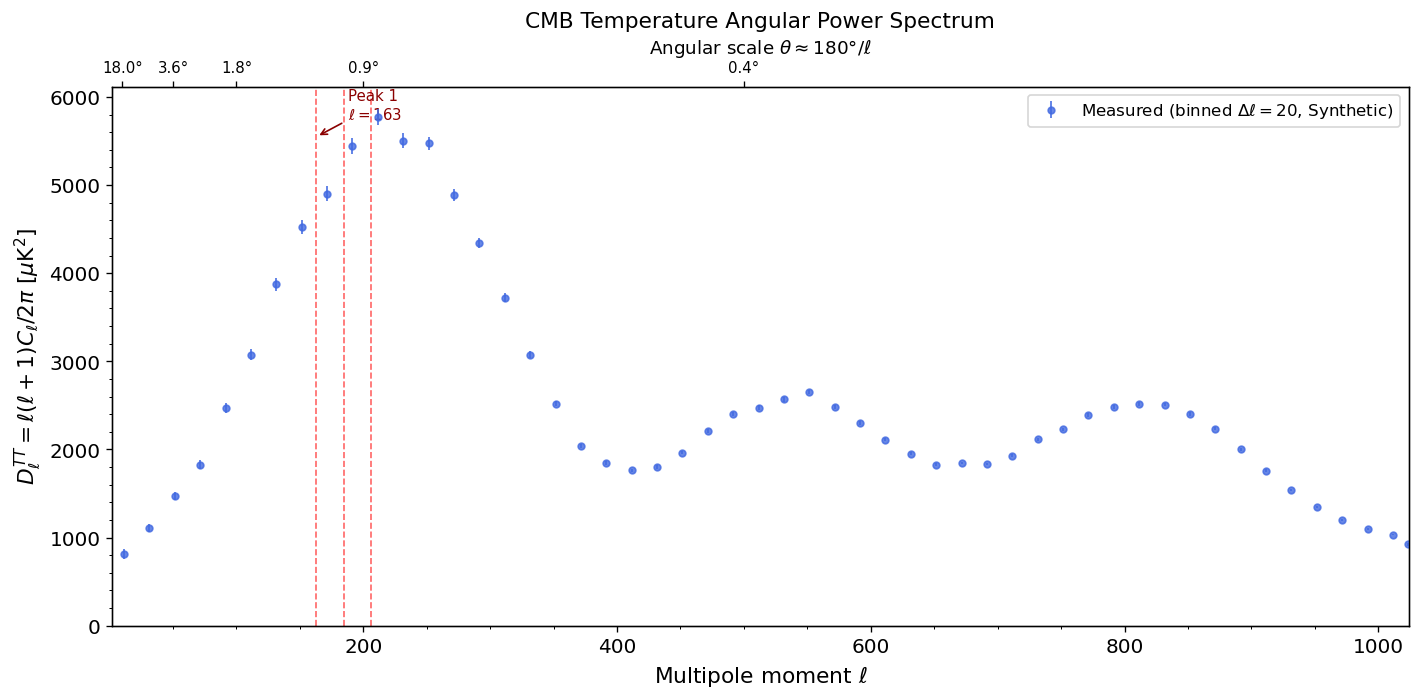

In [6]:
# ── Plot the measured power spectrum ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Apply simple binning for cleaner display
def bin_spectrum(ells, Dl, delta_ell=20):
    """Bin power spectrum in ell bins of width delta_ell."""
    ell_bins   = np.arange(2, ells[-1], delta_ell)
    ell_binned = []
    Dl_binned  = []
    Dl_err     = []
    for e_lo in ell_bins:
        e_hi = e_lo + delta_ell
        mask_bin = (ells >= e_lo) & (ells < e_hi)
        if mask_bin.sum() > 0:
            ell_binned.append(ells[mask_bin].mean())
            Dl_binned.append(Dl[mask_bin].mean())
            # Cosmic variance uncertainty: sigma_Cl/Cl = sqrt(2/(2l+1))
            ell_c = ells[mask_bin].mean()
            Dl_binned_val = Dl[mask_bin].mean()
            # Simplified error: cosmic variance for the bin
            n_modes = mask_bin.sum() * (2 * ell_c + 1)
            sigma_cv = Dl_binned_val * np.sqrt(2.0 / ((2 * ell_c + 1) * mask_bin.sum()))
            Dl_err.append(sigma_cv)
    return (np.array(ell_binned), np.array(Dl_binned), np.array(Dl_err))

ell_binned, Dl_binned, Dl_err = bin_spectrum(ls_measured, Dl_measured, delta_ell=20)

# Plot binned measured spectrum
ax.errorbar(ell_binned, Dl_binned, yerr=Dl_err,
            fmt='o', color='royalblue', ms=4, lw=1.2, alpha=0.8,
            label=f'Measured (binned $\\Delta\\ell=20$, {"Planck SMICA" if use_real_data else "Synthetic"})',
            zorder=5)

# Mark acoustic peaks
for i, (ell_p, Dl_p) in enumerate(zip(peak_ells[:3], peak_Dl[:3])):
    ax.axvline(ell_p, color='red', lw=1, ls='--', alpha=0.6)
    ax.annotate(f'Peak {i+1}\n$\\ell={ell_p}$',
                xy=(ell_p, Dl_p),
                xytext=(ell_p + 25, Dl_p + 200),
                fontsize=9, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.0))

ax.set_xlabel('Multipole moment $\\ell$', fontsize=13)
ax.set_ylabel('$D_\\ell^{TT} = \\ell(\\ell+1)C_\\ell / 2\\pi$ [$\\mu$K$^2$]', fontsize=13)
ax.set_title('CMB Temperature Angular Power Spectrum', fontsize=13)
ax.set_xlim(2, LMAX_WORK)
ax.set_ylim(0, None)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend()

# Add angular scale on top axis
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ell_ticks = [10, 50, 100, 200, 500]
ax_top.set_xticks(ell_ticks)
ax_top.set_xticklabels([f'{180/l:.1f}°' for l in ell_ticks], fontsize=9)
ax_top.set_xlabel('Angular scale $\\theta \\approx 180° / \\ell$', fontsize=11)

plt.tight_layout()
plt.savefig('cmb_power_spectrum_measured.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Theoretical ΛCDM power spectrum from CAMB

We now compute the theoretical CMB power spectrum using **CAMB** (Code for Anisotropies in the Microwave Background; Lewis, Challinor & Lasenby 2000, ApJ 538, 473; arXiv:astro-ph/9911177), with the Planck 2018 best-fit cosmological parameters (Aghanim et al. 2020, A&A 641, A6, Table 2).

CAMB solves the coupled Einstein–Boltzmann equations that describe the evolution of photon, baryon, cold dark matter, and neutrino perturbations from inflation to today.

In [7]:
def compute_camb_spectrum(H0, ombh2, omch2, tau, As, ns, lmax=LMAX_WORK):
    """
    Compute the CMB TT power spectrum D_l using CAMB.

    Parameters
    ----------
    H0 : float
        Hubble constant [km/s/Mpc]
    ombh2 : float
        Physical baryon density Omega_b * h^2
    omch2 : float
        Physical cold dark matter density Omega_cdm * h^2
    tau : float
        Reionisation optical depth
    As : float
        Scalar power spectrum amplitude
    ns : float
        Spectral index
    lmax : int
        Maximum multipole

    Returns
    -------
    ells : array
        Multipole moments 0..lmax
    Dl_TT : array
        TT power spectrum D_l in muK^2
    """
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau)
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_for_lmax(lmax + 50, lens_potential_accuracy=0)

    results = camb.get_results(pars)
    powers  = results.get_cmb_power_spectra(pars, CMB_unit='muK')

    Dl_TT_full = powers['total'][:, 0]   # D_l in muK^2
    ells = np.arange(len(Dl_TT_full))
    return ells[:lmax+1], Dl_TT_full[:lmax+1]


# Compute Planck 2018 best-fit spectrum
print('Computing Planck 2018 best-fit ΛCDM spectrum with CAMB ...')
ell_theory, Dl_theory = compute_camb_spectrum(
    H0=H0_planck, ombh2=omb_h2, omch2=omcdm_h2,
    tau=tau_planck, As=As_planck, ns=ns_planck
)
print(f'Done. Spectrum computed for ell = 0 to {len(ell_theory)-1}.')
print(f'  D_l at ell=220: {Dl_theory[220]:.1f} muK^2  (first acoustic peak)')
print(f'  D_l at ell=540: {Dl_theory[536]:.1f} muK^2  (second acoustic peak)')
print(f'  D_l at ell=813: {Dl_theory[813]:.1f} muK^2  (third acoustic peak)')

# Find peaks in theoretical spectrum
peak_idx_th = argrelmax(Dl_theory[50:], order=30)[0] + 50
print(f'\nCAMB TT peaks: {peak_idx_th[:4]}')

Computing Planck 2018 best-fit ΛCDM spectrum with CAMB ...


Done. Spectrum computed for ell = 0 to 1024.
  D_l at ell=220: 5729.9 muK^2  (first acoustic peak)
  D_l at ell=540: 2593.0 muK^2  (second acoustic peak)
  D_l at ell=813: 2540.9 muK^2  (third acoustic peak)

CAMB TT peaks: [220 536 813]


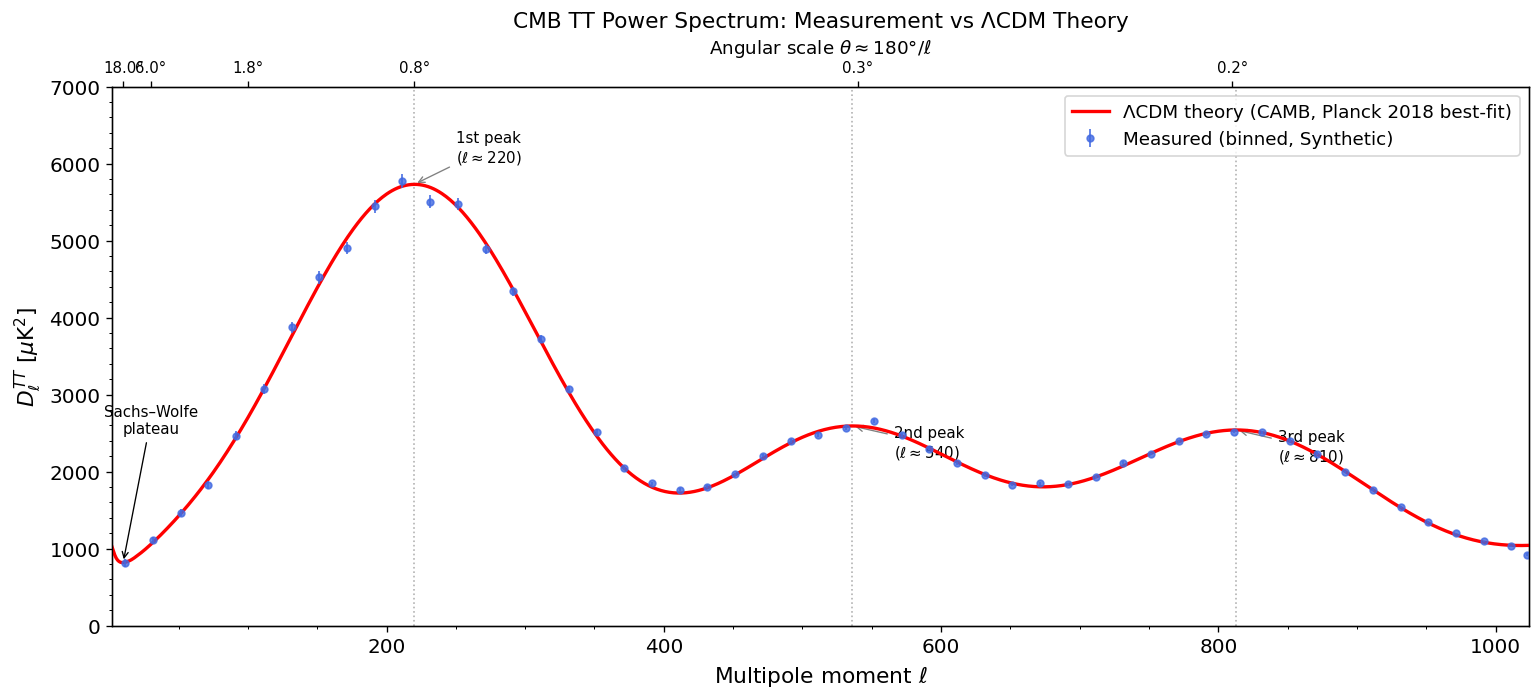

The agreement between measurement and ΛCDM theory is one of the greatest
achievements of modern cosmology: 6 parameters describe the entire spectrum.


In [8]:
# ── Plot measured vs theoretical spectrum ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Measured (binned)
ax.errorbar(ell_binned, Dl_binned, yerr=Dl_err,
            fmt='o', color='royalblue', ms=4, lw=1.2, alpha=0.8, zorder=5,
            label=f'Measured (binned, {"Planck SMICA" if use_real_data else "Synthetic"})')

# Theoretical ΛCDM
ax.plot(ell_theory[2:], Dl_theory[2:], 'r-', lw=2, zorder=4,
        label='ΛCDM theory (CAMB, Planck 2018 best-fit)')

# Mark peaks in theory
peak_labels = ['1st peak\n($\\ell \\approx 220$)',
               '2nd peak\n($\\ell \\approx 540$)',
               '3rd peak\n($\\ell \\approx 810$)']
peak_offsets = [(30, 300), (30, -400), (30, -400)]
for i, idx in enumerate(peak_idx_th[:3]):
    ax.axvline(idx, color='gray', lw=1, ls=':', alpha=0.6)
    ax.annotate(peak_labels[i],
                xy=(idx, Dl_theory[idx]),
                xytext=(idx + peak_offsets[i][0], Dl_theory[idx] + peak_offsets[i][1]),
                fontsize=9, ha='left',
                arrowprops=dict(arrowstyle='->', lw=0.8, color='gray'))

# Sachs-Wolfe plateau label
ax.annotate('Sachs–Wolfe\nplateau', xy=(10, Dl_theory[10]),
            xytext=(30, 2500), fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', lw=0.8))

ax.set_xlabel('Multipole moment $\\ell$', fontsize=13)
ax.set_ylabel('$D_\\ell^{TT}$ [$\\mu$K$^2$]', fontsize=13)
ax.set_title('CMB TT Power Spectrum: Measurement vs ΛCDM Theory', fontsize=13)
ax.set_xlim(2, LMAX_WORK)
ax.set_ylim(0, 7000)
ax.legend(fontsize=11)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Angular scale on top axis
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ell_ticks_top = [10, 30, 100, 220, 540, 810]
ax_top.set_xticks(ell_ticks_top)
ax_top.set_xticklabels([f'{180/l:.1f}°' for l in ell_ticks_top], fontsize=9)
ax_top.set_xlabel('Angular scale $\\theta \\approx 180° / \\ell$', fontsize=11)

plt.tight_layout()
plt.savefig('cmb_power_spectrum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('The agreement between measurement and ΛCDM theory is one of the greatest')
print('achievements of modern cosmology: 6 parameters describe the entire spectrum.')

---

## 8. Parameter sensitivity: how cosmological parameters shape the CMB spectrum

One of the most powerful aspects of CMB science is that the **position, height, and ratio of the acoustic peaks** are sensitive to different cosmological parameters. We now demonstrate this by varying $H_0$, $\Omega_b h^2$, and $\Omega_{\rm cdm} h^2$ one at a time.

### Physical intuition

**Baryon density ($\Omega_b h^2$):** Increasing the baryon-to-photon ratio increases the gravitational restoring force on the fluid. This:
- Enhances the **odd** peaks (compression maxima) relative to the even peaks (rarefaction maxima)
- Shifts the peaks slightly to lower $\ell$ (more mass → slower sound speed → larger angular scale)

**Cold dark matter density ($\Omega_{\rm cdm} h^2$):** More dark matter amplifies the gravitational potential wells. This:
- Increases the overall amplitude of all peaks (gravitational driving)
- Suppresses the even peaks relative to odd peaks (shifts the balance of oscillation)

**Hubble constant ($H_0$):** Changes the angular diameter distance $d_A$ to the last scattering surface. This:
- Shifts all peak positions: larger $H_0$ → larger $d_A$ ... actually the relation is complex (affects multiple factors)
- The position of the first peak is one of the tightest constraints on geometry

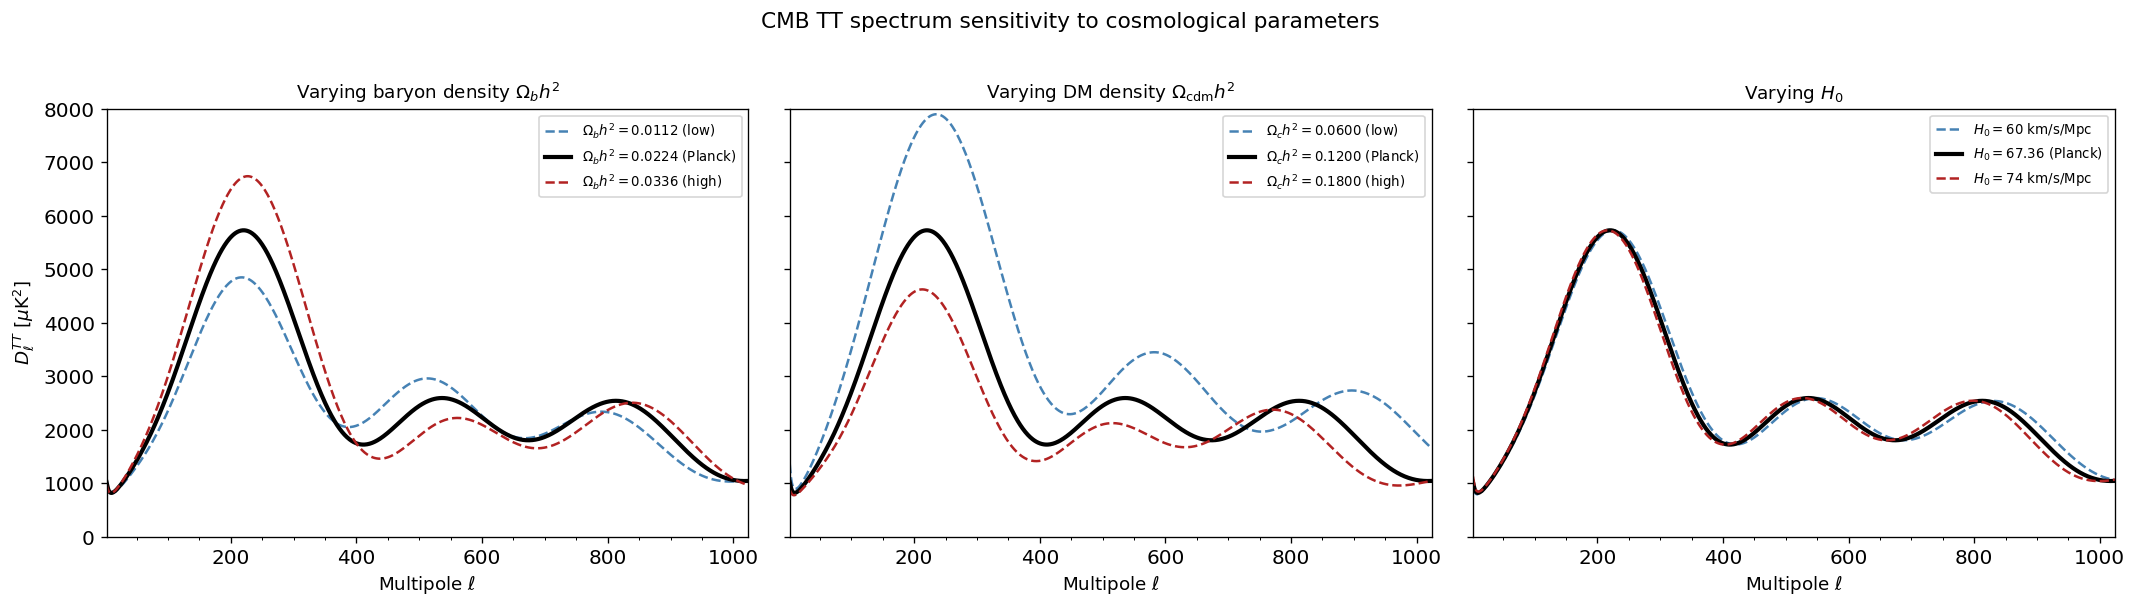

Key effects to observe:
  1. Higher Omega_b -> 1st peak rises, 2nd peak falls (odd/even ratio changes)
  2. Higher Omega_cdm -> all peaks suppressed at high ell (diffusion damping)
  3. H0 variation -> shifts peak positions (changes d_A to last scattering)


In [9]:
# ── Parameter sensitivity plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- Fiducial spectrum -------------------------------------------------------
ell_fid, Dl_fid = ell_theory, Dl_theory   # already computed above

# --- 1. Vary Omega_b h^2 ------------------------------------------------
ax = axes[0]
omb_variants = [
    (omb_h2 * 0.5,  f'$\\Omega_b h^2 = {omb_h2*0.5:.4f}$ (low)',  'steelblue'),
    (omb_h2,        f'$\\Omega_b h^2 = {omb_h2:.4f}$ (Planck)',    'black'),
    (omb_h2 * 1.5,  f'$\\Omega_b h^2 = {omb_h2*1.5:.4f}$ (high)', 'firebrick'),
]
for omb_var, lbl, col in omb_variants:
    lw = 2.5 if omb_var == omb_h2 else 1.5
    ls = '-'  if omb_var == omb_h2 else '--'
    _, Dl_var = compute_camb_spectrum(
        H0=H0_planck, ombh2=omb_var, omch2=omcdm_h2,
        tau=tau_planck, As=As_planck, ns=ns_planck
    )
    ax.plot(ell_theory[2:], Dl_var[2:], color=col, lw=lw, ls=ls, label=lbl)
ax.set_title('Varying baryon density $\\Omega_b h^2$', fontsize=11)
ax.set_xlabel('Multipole $\\ell$', fontsize=11)
ax.set_ylabel('$D_\\ell^{TT}$ [$\\mu$K$^2$]', fontsize=11)
ax.set_xlim(2, LMAX_WORK)
ax.set_ylim(0, 8000)
ax.legend(fontsize=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())

# --- 2. Vary Omega_cdm h^2 ----------------------------------------------
ax2 = axes[1]
omcdm_variants = [
    (omcdm_h2 * 0.5,  f'$\\Omega_c h^2 = {omcdm_h2*0.5:.4f}$ (low)',  'steelblue'),
    (omcdm_h2,        f'$\\Omega_c h^2 = {omcdm_h2:.4f}$ (Planck)',    'black'),
    (omcdm_h2 * 1.5,  f'$\\Omega_c h^2 = {omcdm_h2*1.5:.4f}$ (high)', 'firebrick'),
]
for omcdm_var, lbl, col in omcdm_variants:
    lw = 2.5 if omcdm_var == omcdm_h2 else 1.5
    ls = '-'  if omcdm_var == omcdm_h2 else '--'
    _, Dl_var = compute_camb_spectrum(
        H0=H0_planck, ombh2=omb_h2, omch2=omcdm_var,
        tau=tau_planck, As=As_planck, ns=ns_planck
    )
    ax2.plot(ell_theory[2:], Dl_var[2:], color=col, lw=lw, ls=ls, label=lbl)
ax2.set_title('Varying DM density $\\Omega_{\\rm cdm} h^2$', fontsize=11)
ax2.set_xlabel('Multipole $\\ell$', fontsize=11)
ax2.set_xlim(2, LMAX_WORK)
ax2.legend(fontsize=8)
ax2.xaxis.set_minor_locator(AutoMinorLocator())

# --- 3. Vary H0 ---------------------------------------------------------
ax3 = axes[2]
H0_variants = [
    (60.0,      f'$H_0 = 60$ km/s/Mpc', 'steelblue'),
    (H0_planck, f'$H_0 = {H0_planck:.2f}$ (Planck)',  'black'),
    (74.0,      f'$H_0 = 74$ km/s/Mpc', 'firebrick'),
]
for H0_var, lbl, col in H0_variants:
    lw = 2.5 if H0_var == H0_planck else 1.5
    ls = '-'  if H0_var == H0_planck else '--'
    _, Dl_var = compute_camb_spectrum(
        H0=H0_var, ombh2=omb_h2, omch2=omcdm_h2,
        tau=tau_planck, As=As_planck, ns=ns_planck
    )
    ax3.plot(ell_theory[2:], Dl_var[2:], color=col, lw=lw, ls=ls, label=lbl)
ax3.set_title('Varying $H_0$', fontsize=11)
ax3.set_xlabel('Multipole $\\ell$', fontsize=11)
ax3.set_xlim(2, LMAX_WORK)
ax3.legend(fontsize=8)
ax3.xaxis.set_minor_locator(AutoMinorLocator())

plt.suptitle('CMB TT spectrum sensitivity to cosmological parameters', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('cmb_parameter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key effects to observe:')
print('  1. Higher Omega_b -> 1st peak rises, 2nd peak falls (odd/even ratio changes)')
print('  2. Higher Omega_cdm -> all peaks suppressed at high ell (diffusion damping)')
print('  3. H0 variation -> shifts peak positions (changes d_A to last scattering)')

---

## 9. The CMB blackbody spectrum

The CMB is the most perfect blackbody ever observed. The **FIRAS** instrument on the COBE satellite measured the CMB spectrum from 1990–1992 and found agreement with a blackbody at $T = 2.7255$ K to one part in $10^4$ (Fixsen 2009, ApJ 707, 916).

Let us plot the Planck function at $T = 2.7255$ K and mark the FIRAS frequency range.

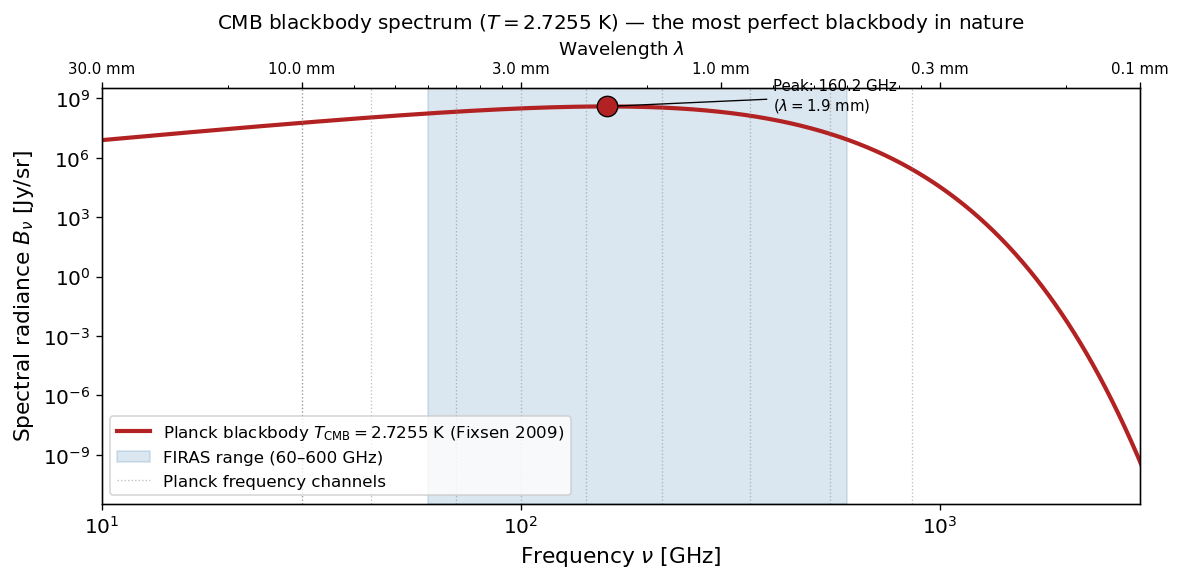

CMB peak frequency (Wien, in nu): nu_max = 160.2 GHz
CMB peak wavelength (in nu):      lambda = 1.87 mm

Note: nu_max(frequency) != c/lambda_max(wavelength) because of the Jacobian.
  Wien peak in wavelength: lambda_max = b_Wien/T = 1.1 mm


In [10]:
from scipy.constants import h as h_planck, c as c_light, k as k_bolt

def B_nu_CMB(nu, T=T_CMB):
    """
    Planck function B_nu for the CMB blackbody.
    Returns spectral radiance in MJy/sr (commonly used in radio/sub-mm).
    """
    nu = np.asarray(nu, dtype=float)
    x = h_planck * nu / (k_bolt * T)
    x = np.minimum(x, 700.0)    # prevent overflow
    B = 2.0 * h_planck * nu**3 / c_light**2 / (np.exp(x) - 1.0)   # W m^-2 Hz^-1 sr^-1
    return B * 1e26   # convert to Jy/sr  (1 Jy = 1e-26 W m^-2 Hz^-1)

# Frequency range: GHz to THz
nu_GHz  = np.logspace(1, 3.5, 1000)   # 10 GHz to ~3 THz
nu_Hz   = nu_GHz * 1e9
B_cmb   = B_nu_CMB(nu_Hz)

fig, ax = plt.subplots(figsize=(10, 5))

ax.loglog(nu_GHz, B_cmb, 'firebrick', lw=2.5,
          label=f'Planck blackbody $T_{{\\mathrm{{CMB}}}} = {T_CMB}$ K (Fixsen 2009)')

# Peak frequency (Wien in frequency: nu_max = 2.821 k_B T / h)
nu_peak_GHz = 2.821 * k_bolt * T_CMB / h_planck / 1e9
B_peak = B_nu_CMB(nu_peak_GHz * 1e9)
ax.scatter([nu_peak_GHz], [B_peak], color='firebrick', s=150, zorder=10,
           edgecolors='k', lw=0.8)
ax.annotate(f'Peak: {nu_peak_GHz:.1f} GHz\n($\\lambda = {c_light/nu_peak_GHz/1e9*1000:.1f}$ mm)',
            xy=(nu_peak_GHz, B_peak),
            xytext=(nu_peak_GHz * 2.5, B_peak * 0.7),
            fontsize=9, arrowprops=dict(arrowstyle='->', lw=0.8))

# FIRAS frequency range (60–600 GHz, i.e. 0.5–5 mm)
ax.axvspan(60, 600, color='steelblue', alpha=0.2, label='FIRAS range (60–600 GHz)')

# Planck satellite frequency channels
planck_freqs = [30, 44, 70, 100, 143, 217, 353, 545, 857]
for nu_ch in planck_freqs:
    ax.axvline(nu_ch, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.axvline(planck_freqs[0], color='gray', lw=0.8, ls=':', alpha=0.5,
           label='Planck frequency channels')

ax.set_xlabel('Frequency $\\nu$ [GHz]', fontsize=13)
ax.set_ylabel('Spectral radiance $B_\\nu$ [Jy/sr]', fontsize=13)
ax.set_title('CMB blackbody spectrum ($T = 2.7255$ K) — the most perfect blackbody in nature',
             fontsize=12)
ax.legend()
ax.set_xlim(10, 3000)
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Add secondary wavelength axis
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
lam_ticks_mm = np.array([0.1, 0.3, 1, 3, 10, 30])
nu_of_lam    = (c_light / (lam_ticks_mm * 1e-3)) / 1e9   # GHz
ax2.set_xticks(nu_of_lam)
ax2.set_xticklabels([f'{l} mm' for l in lam_ticks_mm], fontsize=9)
ax2.set_xlabel('Wavelength $\\lambda$', fontsize=11)

plt.tight_layout()
plt.savefig('cmb_blackbody_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CMB peak frequency (Wien, in nu): nu_max = {nu_peak_GHz:.1f} GHz')
print(f'CMB peak wavelength (in nu):      lambda = {c_light/nu_peak_GHz/1e9*1000:.2f} mm')
print(f'\nNote: nu_max(frequency) != c/lambda_max(wavelength) because of the Jacobian.')
print(f'  Wien peak in wavelength: lambda_max = b_Wien/T = {2.897771955e-3/T_CMB*1000:.1f} mm')

---

## 10. Summary

### Key results

| Quantity | Value | Reference |
|:---------|:------|:----------|
| CMB temperature today | $T_0 = 2.7255 \pm 0.0006$ K | Fixsen (2009) |
| Recombination redshift | $z_\mathrm{rec} \approx 1100$ | $\Lambda$CDM |
| Temperature at recombination | $T_\mathrm{rec} \approx 3000$ K | $= T_0 (1+z_\mathrm{rec})$ |
| CMB temperature anisotropy | $\Delta T / T \sim 10^{-5}$ | Planck 2018 |
| Sound horizon | $r_s \approx 147$ Mpc | Planck 2018 |
| Angular diameter distance to SLS | $d_A \approx 12.9$ Gpc | Planck 2018 |
| First acoustic peak | $\ell_1 \approx 220$ ($\theta \approx 1°$) | Planck 2018 |
| Second acoustic peak | $\ell_2 \approx 540$ | Planck 2018 |
| Third acoustic peak | $\ell_3 \approx 810$ | Planck 2018 |
| Peak amplitude (1st peak) | $D_\ell \approx 5700$ $\mu$K$^2$ | Planck 2018 |

### Cosmological parameters (Planck 2018, Table 2)

| Parameter | Symbol | Planck 2018 value |
|:----------|:-------|:------------------|
| Hubble constant | $H_0$ | $67.36 \pm 0.54$ km/s/Mpc |
| Baryon density | $\Omega_b h^2$ | $0.02237 \pm 0.00015$ |
| Cold dark matter density | $\Omega_{\rm cdm} h^2$ | $0.1200 \pm 0.0012$ |
| Reionisation optical depth | $\tau$ | $0.0544 \pm 0.0073$ |
| Scalar amplitude | $A_s$ | $(2.099 \pm 0.014) \times 10^{-9}$ |
| Spectral index | $n_s$ | $0.9649 \pm 0.0042$ |

---

## 11. Exercises

**Exercise 1 — Temperature at recombination**

If the CMB temperature today is $T_0 = 2.7255$ K and recombination occurred at $z_\mathrm{rec} = 1100$, compute $T_\mathrm{rec} = T_0(1+z_\mathrm{rec})$. How does this compare with the ionisation energy of hydrogen ($E_{\rm ion} = 13.6$ eV, $k_BT = 13.6$ eV gives $T \approx 158\,000$ K)? Why did recombination occur so much later (lower temperature) than this naive estimate?

In [11]:
# Exercise 1: Temperature at recombination
from scipy.constants import k as k_B_SI, eV

T_rec_computed = T_CMB * (1 + z_rec)
print(f'Exercise 1: Temperature at recombination')
print(f'  T_rec = T_CMB * (1 + z_rec) = {T_CMB} * {1+z_rec:.0f} = {T_rec_computed:.0f} K')
print()

# Hydrogen ionisation energy
E_ion_eV = 13.6   # eV
E_ion_J  = E_ion_eV * eV
T_ion_naive = E_ion_J / k_B_SI
print(f'  Naive ionisation temperature: T = E_ion/k_B = {T_ion_naive:.0f} K')
print()
print(f'  T_rec / T_ion_naive = {T_rec_computed / T_ion_naive:.3f}')
print()
print('  Physical explanation: Recombination is delayed to lower T than T_ion_naive')
print('  because of the large photon-to-baryon ratio (~1.6e9 photons per baryon).')
print('  Even at T << T_ion, there are still enough high-energy photons in the')
print('  Wien tail of the Planck spectrum to keep hydrogen ionised.')
print('  This is the Saha equation effect: recombination occurs at T_rec ~ 3000 K')
print('  rather than ~158000 K.')

# Photon-to-baryon ratio
eta_baryon = 6.1e-10   # baryon-to-photon ratio (Planck 2018)
print(f'\n  Baryon-to-photon ratio: eta = n_b/n_gamma = {eta_baryon:.1e}')
print(f'  => ~{1/eta_baryon:.0e} photons per baryon')

Exercise 1: Temperature at recombination
  T_rec = T_CMB * (1 + z_rec) = 2.7255 * 1101 = 3001 K

  Naive ionisation temperature: T = E_ion/k_B = 157821 K

  T_rec / T_ion_naive = 0.019

  Physical explanation: Recombination is delayed to lower T than T_ion_naive
  because of the large photon-to-baryon ratio (~1.6e9 photons per baryon).
  Even at T << T_ion, there are still enough high-energy photons in the
  Wien tail of the Planck spectrum to keep hydrogen ionised.
  This is the Saha equation effect: recombination occurs at T_rec ~ 3000 K
  rather than ~158000 K.

  Baryon-to-photon ratio: eta = n_b/n_gamma = 6.1e-10
  => ~2e+09 photons per baryon


**Exercise 2 — Angular scale of the sound horizon**

Compute the angular scale $\theta_s = r_s / d_A$ corresponding to the sound horizon at recombination, and verify that the first acoustic peak at $\ell_1 \approx 220$ is consistent with $\ell_1 \approx \pi / \theta_s$.

In [12]:
# Exercise 2: Angular scale of sound horizon
print('Exercise 2: Angular scale of the sound horizon')
print(f'  Sound horizon at recombination: r_s = {r_s_Mpc} Mpc')
print(f'  Angular diameter distance to SLS: d_A = {dA_Gpc} Gpc = {dA_Gpc*1000} Mpc')
print()

theta_s_rad = r_s_Mpc / (dA_Gpc * 1000)   # r_s [Mpc] / d_A [Mpc]
theta_s_deg = np.degrees(theta_s_rad)
theta_s_arcmin = theta_s_deg * 60

print(f'  theta_s = r_s / d_A = {r_s_Mpc} / {dA_Gpc*1000:.0f} = {theta_s_rad:.5f} rad')
print(f'           = {theta_s_deg:.3f} degrees = {theta_s_arcmin:.1f} arcmin')
print()

ell_1_predicted = np.pi / theta_s_rad
print(f'  First peak position: ell_1 = pi / theta_s = {ell_1_predicted:.0f}')
print(f'  Observed: ell_1 ~ 220')
print(f'  Agreement: {abs(ell_1_predicted - 220)/220*100:.1f}% offset')
print()
print('  Note: The simple formula ell_1 = pi/theta_s gives ell_1 ~ 210.')
print('  The full numerical calculation (CAMB) gives ell_1 ~ 220 because of')
print('  projection effects, the finite width of the last scattering surface,')
print('  and the shift due to radiation driving.')

Exercise 2: Angular scale of the sound horizon
  Sound horizon at recombination: r_s = 147.0 Mpc
  Angular diameter distance to SLS: d_A = 12.9 Gpc = 12900.0 Mpc

  theta_s = r_s / d_A = 147.0 / 12900 = 0.01140 rad
           = 0.653 degrees = 39.2 arcmin

  First peak position: ell_1 = pi / theta_s = 276
  Observed: ell_1 ~ 220
  Agreement: 25.3% offset

  Note: The simple formula ell_1 = pi/theta_s gives ell_1 ~ 210.
  The full numerical calculation (CAMB) gives ell_1 ~ 220 because of
  projection effects, the finite width of the last scattering surface,
  and the shift due to radiation driving.


**Exercise 3 — The Hubble tension**

The Planck CMB analysis gives $H_0 = 67.36 \pm 0.54$ km/s/Mpc, while local measurements of $H_0$ from the distance ladder (Cepheids + Type Ia supernovae) give $H_0 \approx 73 \pm 1$ km/s/Mpc (Riess et al. 2022, ApJ 934, L7). This **~5σ discrepancy** is called the **Hubble tension**.

Using CAMB, compute the CMB power spectrum for both values of $H_0$ and plot the difference. At which multipoles is the difference largest?

Exercise 3: Impact of the Hubble tension on CMB power spectrum


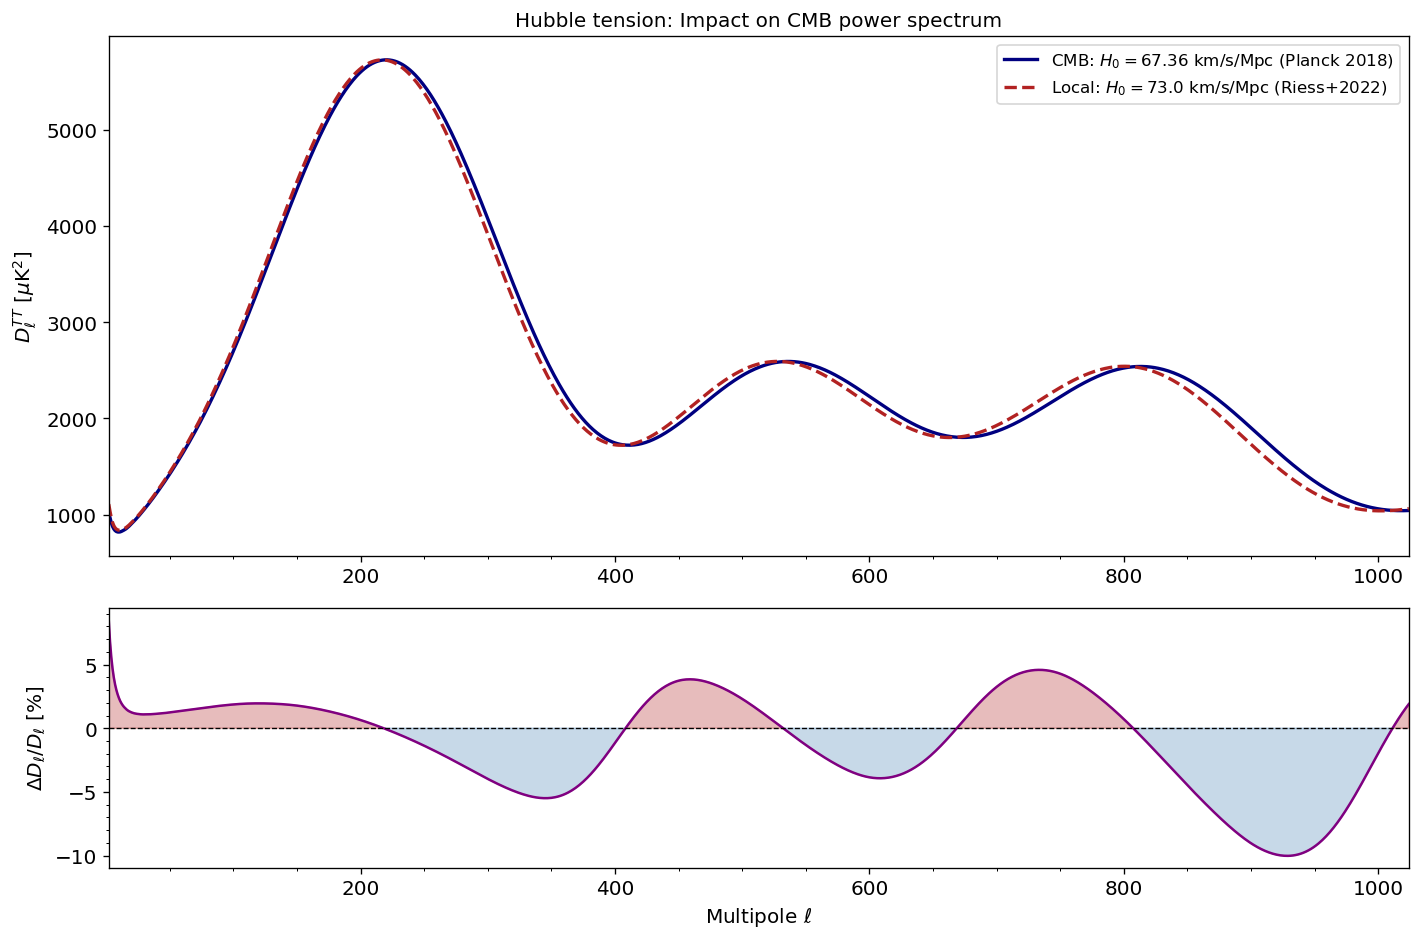

H0 = 67.36: D_l[220] = 5729.9 muK^2
H0 = 73.0:  D_l[220] = 5725.9 muK^2
Fractional difference at ell=220: -0.07%

The Hubble tension (H0=67 vs 73) is a fundamental open problem in cosmology.
Changing H0 alone while keeping other parameters fixed gives ~0.1% change
in the CMB; but a full parameter fit would shift Omega_m to compensate.


In [13]:
# Exercise 3: Hubble tension - CMB implications
print('Exercise 3: Impact of the Hubble tension on CMB power spectrum')

# Compute spectra for Planck H0 and local H0
H0_Planck_val = 67.36
H0_local_val  = 73.0   # Riess et al. 2022

_, Dl_H0_planck = compute_camb_spectrum(
    H0=H0_Planck_val, ombh2=omb_h2, omch2=omcdm_h2,
    tau=tau_planck, As=As_planck, ns=ns_planck
)
_, Dl_H0_local = compute_camb_spectrum(
    H0=H0_local_val, ombh2=omb_h2, omch2=omcdm_h2,
    tau=tau_planck, As=As_planck, ns=ns_planck
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                          gridspec_kw={'height_ratios': [2, 1]})

# Top panel: spectra
ax = axes[0]
ell_p = ell_theory
ax.plot(ell_p[2:], Dl_H0_planck[2:], 'navy', lw=2,
        label=f'CMB: $H_0 = {H0_Planck_val}$ km/s/Mpc (Planck 2018)')
ax.plot(ell_p[2:], Dl_H0_local[2:], 'firebrick', lw=2, ls='--',
        label=f'Local: $H_0 = {H0_local_val}$ km/s/Mpc (Riess+2022)')
ax.set_ylabel('$D_\\ell^{TT}$ [$\\mu$K$^2$]', fontsize=12)
ax.set_title('Hubble tension: Impact on CMB power spectrum', fontsize=12)
ax.legend()
ax.set_xlim(2, LMAX_WORK)
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Bottom panel: fractional difference
ax2 = axes[1]
Dl_ratio = (Dl_H0_local[2:] - Dl_H0_planck[2:]) / Dl_H0_planck[2:] * 100
ell_plot  = ell_p[2:]
ax2.plot(ell_plot, Dl_ratio, 'purple', lw=1.5)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.fill_between(ell_plot, Dl_ratio, 0,
                 where=Dl_ratio > 0, alpha=0.3, color='firebrick')
ax2.fill_between(ell_plot, Dl_ratio, 0,
                 where=Dl_ratio < 0, alpha=0.3, color='steelblue')
ax2.set_xlabel('Multipole $\\ell$', fontsize=12)
ax2.set_ylabel(f'$\\Delta D_\\ell / D_\\ell$ [%]', fontsize=12)
ax2.set_xlim(2, LMAX_WORK)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('hubble_tension_cmb.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'H0 = {H0_Planck_val}: D_l[220] = {Dl_H0_planck[220]:.1f} muK^2')
print(f'H0 = {H0_local_val}:  D_l[220] = {Dl_H0_local[220]:.1f} muK^2')
print(f'Fractional difference at ell=220: {(Dl_H0_local[220]-Dl_H0_planck[220])/Dl_H0_planck[220]*100:.2f}%')
print()
print('The Hubble tension (H0=67 vs 73) is a fundamental open problem in cosmology.')
print('Changing H0 alone while keeping other parameters fixed gives ~0.1% change')
print('in the CMB; but a full parameter fit would shift Omega_m to compensate.')

**Exercise 4 — Odd/even peak ratio and baryon density**

The ratio of the first to second acoustic peak amplitude $D_\ell(\ell_1) / D_\ell(\ell_2)$ is a sensitive measure of the baryon density $\Omega_b h^2$. Compute this ratio for three values of $\Omega_b h^2$ (0.5×, 1×, 1.5× the Planck value) and quantify how the ratio changes.

In [14]:
# Exercise 4: Odd/even peak ratio vs baryon density
print('Exercise 4: First-to-second peak ratio vs baryon density')
print()
print(f'{"Omega_b h^2":>15}  {"D_l(ell_1)":>12}  {"D_l(ell_2)":>12}  {"Ratio":>8}')
print('-' * 55)

for scale in [0.5, 1.0, 1.5]:
    omb_test = omb_h2 * scale
    _, Dl_test = compute_camb_spectrum(
        H0=H0_planck, ombh2=omb_test, omch2=omcdm_h2,
        tau=tau_planck, As=As_planck, ns=ns_planck
    )
    # Find peak 1 near ell=220 and peak 2 near ell=536
    D1 = Dl_test[200:260].max()    # first peak: max in [200, 260]
    D2 = Dl_test[490:580].max()    # second peak: max in [490, 580]
    ratio = D1 / D2
    marker = ' <-- Planck' if scale == 1.0 else ''
    print(f'{omb_test:>15.5f}  {D1:>12.1f}  {D2:>12.1f}  {ratio:>8.3f}{marker}')

print()
print('Higher baryon density -> higher 1st peak, lower 2nd peak -> larger ratio.')
print('This is the acoustic lever arm: more baryons increase the amplitude of')
print('compression peaks (odd) relative to rarefaction peaks (even).')

Exercise 4: First-to-second peak ratio vs baryon density

    Omega_b h^2    D_l(ell_1)    D_l(ell_2)     Ratio
-------------------------------------------------------


        0.01119        4849.6        2959.5     1.639


        0.02237        5729.9        2593.0     2.210 <-- Planck


        0.03356        6741.2        2220.3     3.036

Higher baryon density -> higher 1st peak, lower 2nd peak -> larger ratio.
This is the acoustic lever arm: more baryons increase the amplitude of
compression peaks (odd) relative to rarefaction peaks (even).


---

## 12. Further reading

- **Planck Collaboration, Aghanim et al.** (2020), A&A 641, A6 — Planck 2018 results VI: Cosmological parameters. [arXiv:1807.06209](https://arxiv.org/abs/1807.06209)
- **Planck Collaboration, Akrami et al.** (2020), A&A 641, A4 — Planck 2018 results IV: CMB map-making. [arXiv:1807.06208](https://arxiv.org/abs/1807.06208)
- **Fixsen** (2009), ApJ 707, 916 — The temperature of the cosmic microwave background. [arXiv:0911.1955](https://arxiv.org/abs/0911.1955)
- **Lewis, Challinor & Lasenby** (2000), ApJ 538, 473 — Efficient computation of CMB anisotropies (CAMB). [arXiv:astro-ph/9911177](https://arxiv.org/abs/astro-ph/9911177)
- **Dodelson** (2003), *Modern Cosmology*, Academic Press — thorough treatment of CMB physics
- **Baumann** (2022), *Cosmology*, Cambridge University Press — graduate-level, free online: [http://cosmology.amsterdam/](http://cosmology.amsterdam/)
- **Wayne Hu's CMB tutorials:** [https://background.uchicago.edu/~whu/physics/physics.html](https://background.uchicago.edu/~whu/physics/physics.html)
- **Górski et al.** (2005), ApJ 622, 759 — HEALPix: A Framework for High-Resolution Discretization
- **CAMB documentation:** [https://camb.readthedocs.io/](https://camb.readthedocs.io/)
- **Planck Legacy Archive:** [https://pla.esac.esa.int/](https://pla.esac.esa.int/) — download all Planck data products